# NCF Model Training

In [1]:
import json
import sys
from pathlib import Path

sys.path.append('../src')

for stale_module in ['model', 'data_utils']:
    sys.modules.pop(stale_module, None)

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

from data_utils import prepare_full_pipeline, leave_last_n_out_split
from model import NCFModel, RatingsDataset

## Load and preprocess data

In [2]:
data = prepare_full_pipeline(test_n=1)
train_val_df = data['train_df']
test_df = data['test_df']
mappings = data['mappings']
genre_feature_matrix = data['genre_feature_matrix']

train_df, val_df = leave_last_n_out_split(train_val_df, n=1, min_ratings=3)
train_df.shape, val_df.shape, test_df.shape

((99616, 4), (610, 4), (610, 4))

## Build datasets and model

In [3]:
embed_dim = 32
batch_size = 256
num_epochs = 15
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_dataset = RatingsDataset(train_df, mappings.user_to_idx, mappings.movie_to_idx, genre_feature_matrix)
val_dataset = RatingsDataset(val_df, mappings.user_to_idx, mappings.movie_to_idx, genre_feature_matrix)
test_dataset = RatingsDataset(test_df, mappings.user_to_idx, mappings.movie_to_idx, genre_feature_matrix)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = NCFModel(
    num_users=len(mappings.user_to_idx),
    num_movies=len(mappings.movie_to_idx),
    num_genres=len(mappings.genre_names),
    embed_dim=embed_dim,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()
device

'cpu'

## Train the NCF model

In [4]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    num_train_samples = 0
    for user_idx, movie_idx, genre_features, rating in train_loader:
        user_idx = user_idx.to(device)
        movie_idx = movie_idx.to(device)
        genre_features = genre_features.to(device)
        rating = rating.to(device)

        optimizer.zero_grad()
        predictions = model(user_idx, movie_idx, genre_features)
        loss = loss_fn(predictions, rating)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item() * len(rating)
        num_train_samples += len(rating)

    avg_train_loss = epoch_train_loss / num_train_samples
    train_losses.append(avg_train_loss)

    model.eval()
    epoch_val_loss = 0.0
    num_val_samples = 0
    with torch.no_grad():
        for user_idx, movie_idx, genre_features, rating in val_loader:
            user_idx = user_idx.to(device)
            movie_idx = movie_idx.to(device)
            genre_features = genre_features.to(device)
            rating = rating.to(device)

            predictions = model(user_idx, movie_idx, genre_features)
            loss = loss_fn(predictions, rating)
            epoch_val_loss += loss.item() * len(rating)
            num_val_samples += len(rating)

    avg_val_loss = epoch_val_loss / num_val_samples
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch + 1}/{num_epochs} - train_loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}')

Epoch 1/15 - train_loss: 2.6731 - val_loss: 1.0511


Epoch 2/15 - train_loss: 1.3532 - val_loss: 1.0084


Epoch 3/15 - train_loss: 1.2585 - val_loss: 0.9822


Epoch 4/15 - train_loss: 1.1953 - val_loss: 0.9827


Epoch 5/15 - train_loss: 1.1375 - val_loss: 0.8958


...

Epoch 11/15 - train_loss: 0.8747 - val_loss: 0.8450


Epoch 12/15 - train_loss: 0.8399 - val_loss: 0.8227


Epoch 13/15 - train_loss: 0.8092 - val_loss: 0.8245


Epoch 14/15 - train_loss: 0.7847 - val_loss: 0.8122


Epoch 15/15 - train_loss: 0.7619 - val_loss: 0.8222


## Loss curves

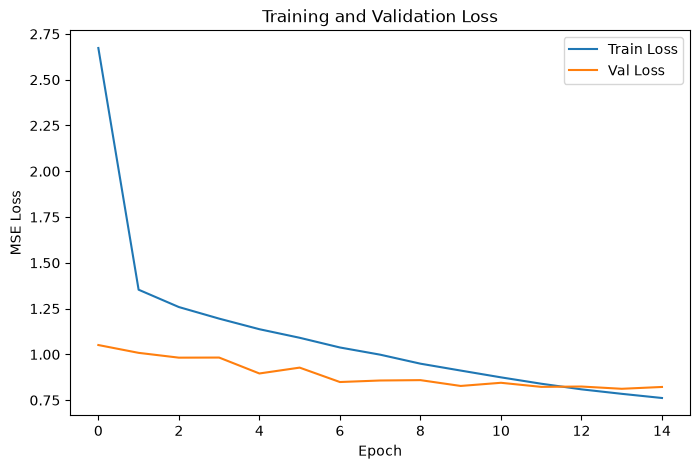

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Evaluate on held-out test set

In [6]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for user_idx, movie_idx, genre_features, rating in test_loader:
        user_idx = user_idx.to(device)
        movie_idx = movie_idx.to(device)
        genre_features = genre_features.to(device)

        predictions = model(user_idx, movie_idx, genre_features)
        all_predictions.extend(predictions.cpu().numpy().tolist())
        all_targets.extend(rating.numpy().tolist())

rmse = float(np.sqrt(mean_squared_error(all_targets, all_predictions)))
mae = float(mean_absolute_error(all_targets, all_predictions))

print(f'Test RMSE: {rmse:.4f}')
print(f'Test MAE: {mae:.4f}')

Test RMSE: 0.9860
Test MAE: 0.7720


## Save artifacts

In [7]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), models_dir / 'ncf_model.pt')
np.save(models_dir / 'genre_feature_matrix.npy', genre_feature_matrix)

mappings_payload = {
    'user_to_idx': {str(int(k)): int(v) for k, v in mappings.user_to_idx.items()},
    'idx_to_user': {str(int(k)): int(v) for k, v in mappings.idx_to_user.items()},
    'movie_to_idx': {str(int(k)): int(v) for k, v in mappings.movie_to_idx.items()},
    'idx_to_movie': {str(int(k)): int(v) for k, v in mappings.idx_to_movie.items()},
    'genre_names': mappings.genre_names,
    'embed_dim': embed_dim,
}
with open(models_dir / 'mappings.json', 'w') as f:
    json.dump(mappings_payload, f)

print('Artifacts saved to ../models')

Artifacts saved to ../models
